In [ ]:
%pip install pandas -U
%pip install scipy -U
%pip install seaborn -U
%pip install matplotlib -U
%pip install scikit-learn -U

In [2]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### 1.a)
    En nan rad i vær datasettet som er droppet, er også en bindestrek i trafikk datasettet som ble omgjort til 0.

In [3]:
tdf = pd.read_csv("data/lysakelysaker_tellinger.csv", sep=";")
vdf = pd.read_csv("data/lysaker_vær.csv", sep=";")

display(tdf.head(),
vdf.head(), "Tail", tdf.tail(),vdf.tail())

,Trafikkregistreringspunkt,Navn,Vegreferanse,Fra,Til,Dato,Fra tidspunkt,Til tidspunkt,Felt,Trafikkmengde
0,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T00:00+01:00,2025-01-01T01:00+01:00,2025-01-01,00:00,01:00,1,0
1,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T01:00+01:00,2025-01-01T02:00+01:00,2025-01-01,01:00,02:00,1,0
2,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T02:00+01:00,2025-01-01T03:00+01:00,2025-01-01,02:00,03:00,1,0
3,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T03:00+01:00,2025-01-01T04:00+01:00,2025-01-01,03:00,04:00,1,0
4,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T04:00+01:00,2025-01-01T05:00+01:00,2025-01-01,04:00,05:00,1,0


,lokasjon,stasjon,dato,temperatur_dogn,nedbor_dogn
0,Lysaker,SN18810,01.01.2025,"-3,9","4,1"
1,Lysaker,SN18810,02.01.2025,-7,"0,2"
2,Lysaker,SN18810,03.01.2025,"-6,3","0,1"
3,Lysaker,SN18810,04.01.2025,"-11,4",0
4,Lysaker,SN18810,05.01.2025,"-10,6",0


'Tail'

,Trafikkregistreringspunkt,Navn,Vegreferanse,Fra,Til,Dato,Fra tidspunkt,Til tidspunkt,Felt,Trafikkmengde
15691,79755V625294,Maritim,EV18 S55D1 m1514,2025-11-23T19:00+01:00,2025-11-23T20:00+01:00,2025-11-23,19:00,20:00,Totalt i retning Drammen,1812
15692,79755V625294,Maritim,EV18 S55D1 m1514,2025-11-23T20:00+01:00,2025-11-23T21:00+01:00,2025-11-23,20:00,21:00,Totalt i retning Drammen,1581
15693,79755V625294,Maritim,EV18 S55D1 m1514,2025-11-23T21:00+01:00,2025-11-23T22:00+01:00,2025-11-23,21:00,22:00,Totalt i retning Drammen,1123
15694,79755V625294,Maritim,EV18 S55D1 m1514,2025-11-23T22:00+01:00,2025-11-23T23:00+01:00,2025-11-23,22:00,23:00,Totalt i retning Drammen,803
15695,79755V625294,Maritim,EV18 S55D1 m1514,2025-11-23T23:00+01:00,2025-11-24T00:00+01:00,2025-11-23,23:00,00:00,Totalt i retning Drammen,462


,lokasjon,stasjon,dato,temperatur_dogn,nedbor_dogn
323,Lysaker,SN18810,20.11.2025,"-3,9",0
324,Lysaker,SN18810,21.11.2025,"-4,7",0
325,Lysaker,SN18810,22.11.2025,"0,2","0,2"
326,Lysaker,SN18810,23.11.2025,4,4
327,Lysaker,NaN,NaN,NaN,NaN


In [4]:
tdf.columns = tdf.columns.str.lower().str.replace(r'(?<=trafikk)([a-z])', r'_\1', regex=True)
tdf.head()

,trafikk_registreringspunkt,navn,vegreferanse,fra,til,dato,fra tidspunkt,til tidspunkt,felt,trafikk_mengde
0,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T00:00+01:00,2025-01-01T01:00+01:00,2025-01-01,00:00,01:00,1,0
1,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T01:00+01:00,2025-01-01T02:00+01:00,2025-01-01,01:00,02:00,1,0
2,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T02:00+01:00,2025-01-01T03:00+01:00,2025-01-01,02:00,03:00,1,0
3,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T03:00+01:00,2025-01-01T04:00+01:00,2025-01-01,03:00,04:00,1,0
4,55912B613537,Lysaker sykkel,EV18 S55D100 m29,2025-01-01T04:00+01:00,2025-01-01T05:00+01:00,2025-01-01,04:00,05:00,1,0


In [5]:
print("traffikk dataframe:",tdf.shape,"\nvær dataframe:",vdf.shape)

traffikk dataframe: (15696, 10) 
vær dataframe: (328, 5)


In [6]:
def vis_nanull_values(_tdf=tdf,_vdf=vdf):
    print("Trafikk data")
    print(_tdf.isnull().sum())
    print(f"\n|{'-'*30}|\n")
    print("Vær data")
    print(_vdf.isnull().sum())
vis_nanull_values()

Trafikk data
trafikk_registreringspunkt    0
navn                          0
vegreferanse                  0
fra                           0
til                           0
dato                          0
fra tidspunkt                 0
til tidspunkt                 0
felt                          0
trafikk_mengde                0
dtype: int64

|------------------------------|

Vær data
lokasjon           0
stasjon            1
dato               1
temperatur_dogn    1
nedbor_dogn        1
dtype: int64


In [7]:
htdf = tdf[tdf["trafikk_mengde"] == "-"]
print("Count: " + str(htdf.shape[0]))
htdf

Count: 1


,trafikk_registreringspunkt,navn,vegreferanse,fra,til,dato,fra tidspunkt,til tidspunkt,felt,trafikk_mengde
9731,79755V625294,Maritim,EV18 S55D1 m1514,2025-03-20T11:00+01:00,2025-03-20T12:00+01:00,2025-03-20,11:00,12:00,Totalt i retning Drammen,-


In [8]:
tdf.loc[htdf.index,'trafikk_mengde'] = 0
vdf = vdf.dropna().copy()
htdf = tdf[tdf["trafikk_mengde"] == "-"]
print("Count: " + str(htdf.shape[0]))
display(htdf)
vis_nanull_values(tdf,vdf)

Count: 0


,trafikk_registreringspunkt,navn,vegreferanse,fra,til,dato,fra tidspunkt,til tidspunkt,felt,trafikk_mengde


Trafikk data
trafikk_registreringspunkt    0
navn                          0
vegreferanse                  0
fra                           0
til                           0
dato                          0
fra tidspunkt                 0
til tidspunkt                 0
felt                          0
trafikk_mengde                0
dtype: int64

|------------------------------|

Vær data
lokasjon           0
stasjon            0
dato               0
temperatur_dogn    0
nedbor_dogn        0
dtype: int64


In [9]:
tdf['dato'] = pd.to_datetime(tdf['dato'])
tdf['måne'] = tdf['dato'].dt.month
tdf['uke'] = tdf['dato'].dt.isocalendar().week
tdf['år'] = tdf['dato'].dt.isocalendar().year
tdf['dag'] = tdf['dato'].dt.isocalendar().day
from_to_date = tdf[['fra','til']].apply(lambda ds:pd.to_datetime(ds,utc=True))
tdf['time'] = (from_to_date['til'] - from_to_date['fra']).dt.total_seconds() / 3600
tdf['time'] = (tdf.copy().groupby(['trafikk_registreringspunkt','dato'])['time'].cumsum()).astype(int)
display(tdf[['fra','til','trafikk_mengde','år','måne','uke','dag','time']])

,fra,til,trafikk_mengde,år,måne,uke,dag,time
0,2025-01-01T00:00+01:00,2025-01-01T01:00+01:00,0,2025,1,1,3,1
1,2025-01-01T01:00+01:00,2025-01-01T02:00+01:00,0,2025,1,1,3,2
2,2025-01-01T02:00+01:00,2025-01-01T03:00+01:00,0,2025,1,1,3,3
3,2025-01-01T03:00+01:00,2025-01-01T04:00+01:00,0,2025,1,1,3,4
4,2025-01-01T04:00+01:00,2025-01-01T05:00+01:00,0,2025,1,1,3,5
...,...,...,...,...,...,...,...,...
15691,2025-11-23T19:00+01:00,2025-11-23T20:00+01:00,1812,2025,11,47,7,20
15692,2025-11-23T20:00+01:00,2025-11-23T21:00+01:00,1581,2025,11,47,7,21
15693,2025-11-23T21:00+01:00,2025-11-23T22:00+01:00,1123,2025,11,47,7,22
15694,2025-11-23T22:00+01:00,2025-11-23T23:00+01:00,803,2025,11,47,7,23


### 1.b)
    Ser ikke ut til at det er måle feil. Mulig 03-20 11:00-12:00 var en sensordefekt iåmed at d var "highfin" verdi der. August så ser d ut til ha vert endring i kjøre mønster som muligens har senket trafikken noe i 2 måner. Litt intresant at Januar har utliggere, men ser ikke ut at d er noe serlig stor forskjell.

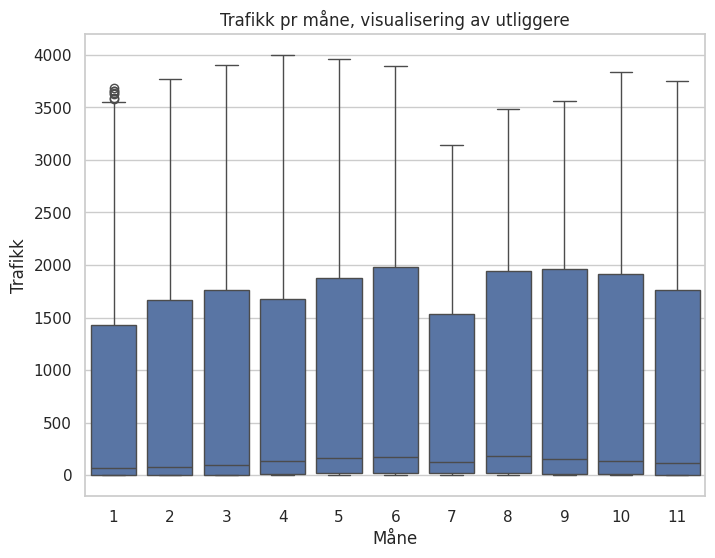

In [51]:
# Identifiser uvanlige eller ekstreme verdier i trafikkmengdene
plt.figure(figsize=(8, 6))
sns.boxplot(x=tdf['måne'],y=tdf['trafikk_mengde'])
plt.title('Trafikk pr måne, visualisering av utliggere')
plt.ylabel('Trafikk')
plt.xlabel('Måne')
plt.show()

<!--1.c) Finn og beskriv perioder (dager eller timer) som skiller seg tydelig ut fra normalt aktivitetsnivå.-->
### 1.c)
    Natt skiller seg ut og søndager skiller seg ut

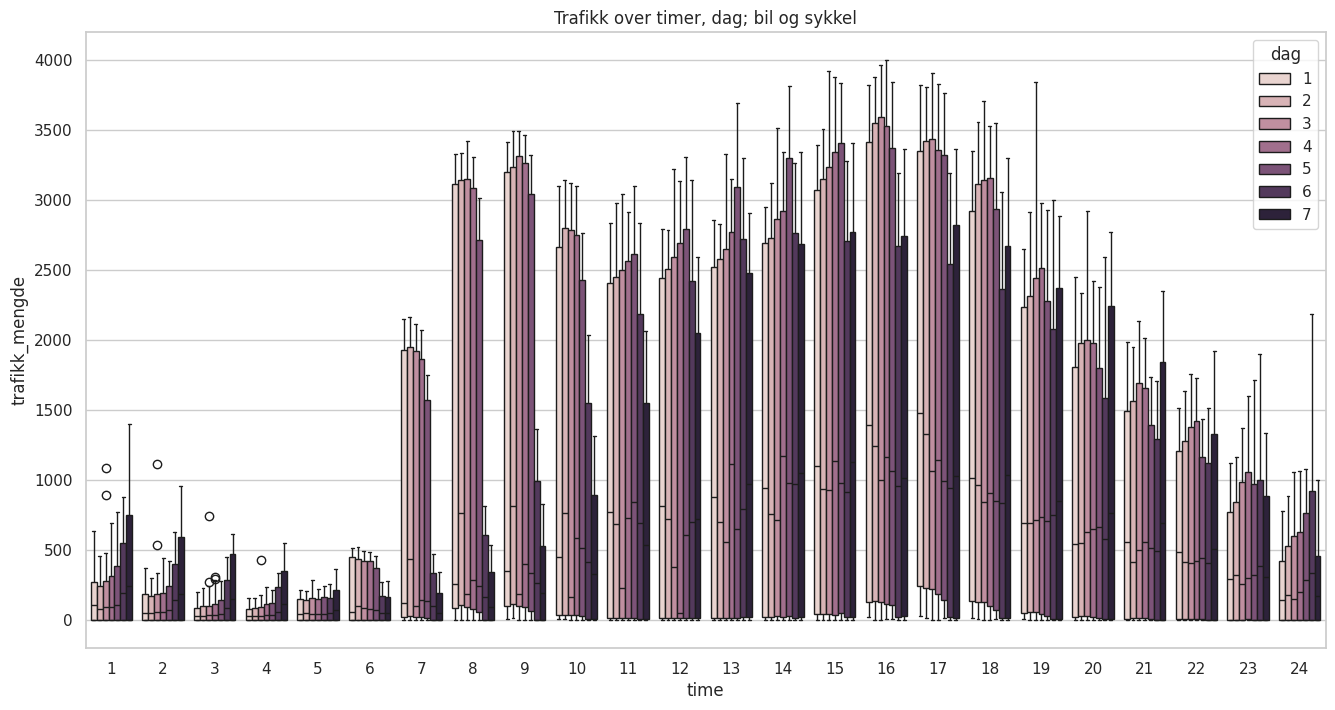

In [52]:
plt.figure(figsize=(16, 8))
plot_df = tdf.copy()
plot_df.loc[plot_df['time'] == 25, 'time'] = 24 # fra , til convertering til timmer la 2 "entries" på 25 en fra sykkel og en bil
plot_df['dag'] = plot_df['dag'].astype('int64')
plot_df['time'] = plot_df['time'].astype('int64')
sns.boxplot(x=plot_df["time"],y=plot_df['trafikk_mengde'], hue=plot_df['dag'])
plt.title('Trafikk over timer, dag; bil og sykkel')
plt.show()

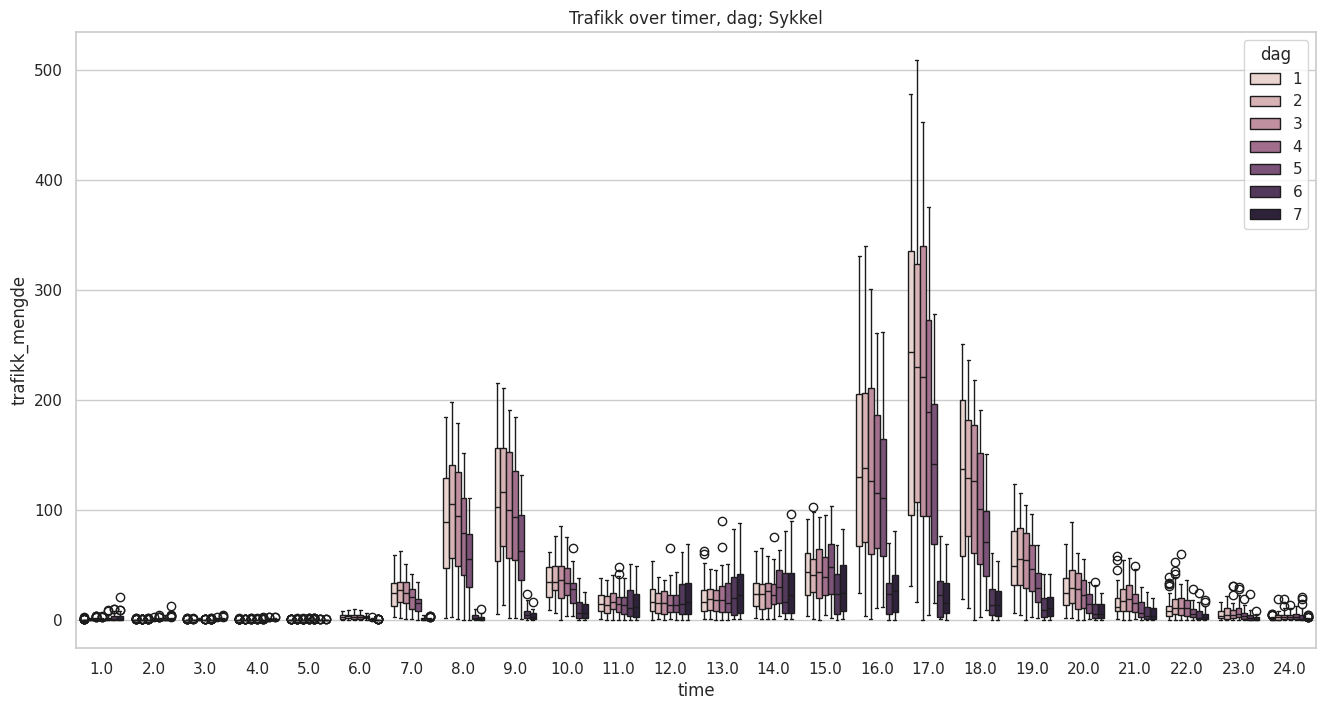

In [53]:
plt.figure(figsize=(16, 8))
plot_df_sykkel = plot_df[plot_df['trafikk_registreringspunkt'] == '55912B613537'].copy()
sns.boxplot(x=plot_df_sykkel["time"],y=plot_df['trafikk_mengde'], hue=plot_df['dag'])
plt.title('Trafikk over timer, dag; Sykkel')
plt.show()

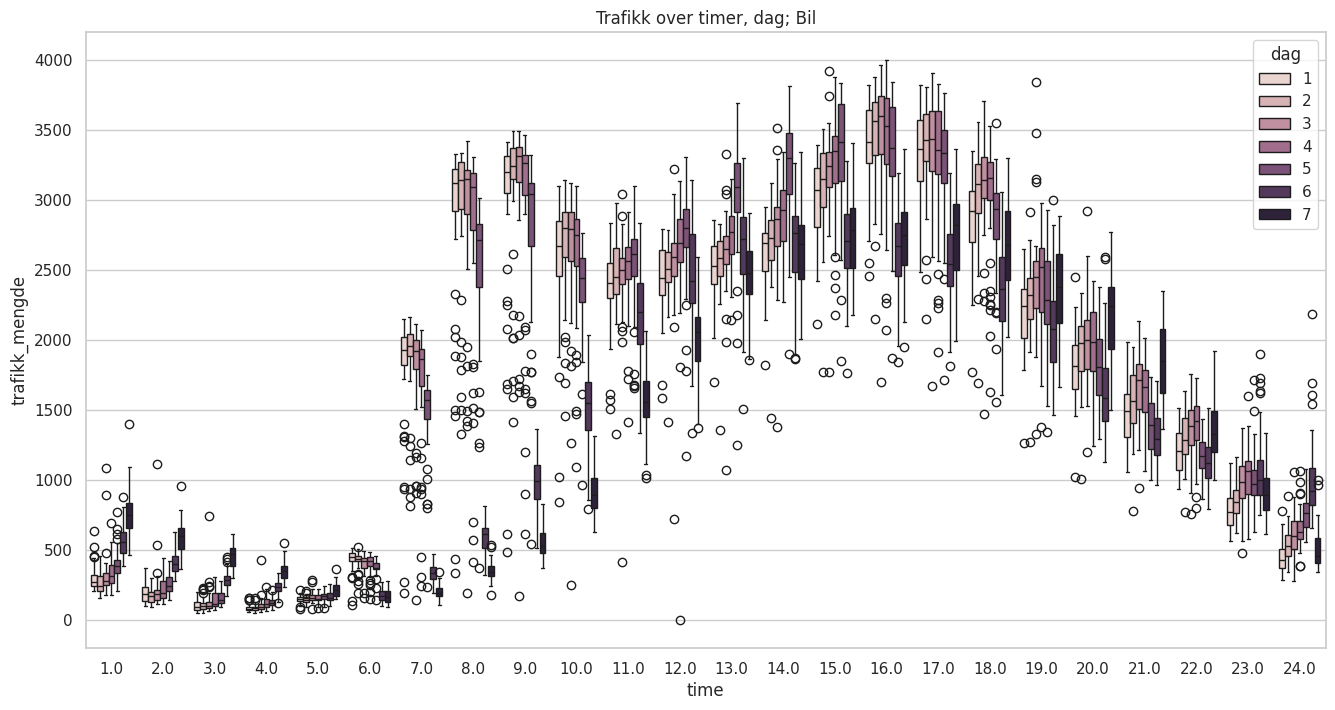

In [54]:
plt.figure(figsize=(16, 8))
plot_df_bil = plot_df[plot_df['trafikk_registreringspunkt'] == '79755V625294']
sns.boxplot(x=plot_df_bil["time"],y=plot_df['trafikk_mengde'], hue=plot_df['dag'])
plt.title('Trafikk over timer, dag; Bil')
plt.show()

<!--1.d) Diskuter om slike anomalier kan påvirke statistiske mål som gjennomsnitt, korrelasjon eller klyngeanalyse.-->
### 1.d)
    Anomelier vil alltid påvirke gjenomsnitt, statiskiske analyser og korelasjons analyser.

In [10]:
print(tdf[['trafikk_registreringspunkt', 'navn', 'år', 'uke','dag','time']].dtypes)
print(tdf[['trafikk_registreringspunkt', 'navn', 'år', 'uke']].isna().sum())
tdf['trafikk_mengde']= pd.to_numeric(tdf['trafikk_mengde'].astype('str')).astype('UInt32')

trafikk_registreringspunkt    object
navn                          object
år                            UInt32
uke                           UInt32
dag                           UInt32
time                           int64
dtype: object
trafikk_registreringspunkt    0
navn                          0
år                            0
uke                           0
dtype: int64


In [11]:
# ./output_utils.py
from output_utils import side_by_side

# høyest gjennomsnittlig sykkeltrafikk og høyest biltrafikk.
week_mean_traffic = tdf.copy().groupby(['trafikk_registreringspunkt','navn','år','uke']).agg({'trafikk_mengde':'mean'}).reset_index()
time_mean_traffic = tdf.copy().groupby(['trafikk_registreringspunkt','navn','år','dag','uke','time']).agg({'trafikk_mengde':'mean'}).reset_index()

week_desc_s_traffic = week_mean_traffic[week_mean_traffic['navn'].str.contains('sykkel', case=False)].sort_values(by='trafikk_mengde',ascending=False)
week_desc_c_traffic = week_mean_traffic[week_mean_traffic['navn'] == 'Maritim'].sort_values(by='trafikk_mengde',ascending=False)

time_desc_s_traffic = time_mean_traffic[time_mean_traffic['navn'].str.contains('sykkel', case=False)].sort_values(by='trafikk_mengde',ascending=False)
time_desc_c_traffic = time_mean_traffic[time_mean_traffic['navn'] == 'Maritim'].sort_values(by='trafikk_mengde',ascending=False)

# hel nummer til uint
time_desc_c_traffic['trafikk_mengde'] = time_desc_c_traffic['trafikk_mengde'].astype('UInt32')
time_desc_s_traffic['trafikk_mengde'] = time_desc_s_traffic['trafikk_mengde'].astype('UInt32')

# side ved side visualisering av tab
side_by_side(week_desc_s_traffic.head(5), week_desc_c_traffic.head(5), captions=['Sykkel Gjennomsnitt Uke', 'Bil Gjennomsnitt Uke'])
side_by_side(time_desc_s_traffic.head(5), time_desc_c_traffic.head(5),captions=['Sykkel Gjennomsnitt Time', 'Bil Gjennomsnitt Time'])

,trafikk_registreringspunkt,navn,år,uke,trafikk_mengde
33,55912B613537,Lysaker sykkel,2025,34,58.095238
32,55912B613537,Lysaker sykkel,2025,33,57.125
19,55912B613537,Lysaker sykkel,2025,20,52.565476
24,55912B613537,Lysaker sykkel,2025,25,52.470238
18,55912B613537,Lysaker sykkel,2025,19,50.791667
,trafikk_registreringspunkt,navn,år,uke,trafikk_mengde
71,79755V625294,Maritim,2025,25,1911.244048
70,79755V625294,Maritim,2025,24,1884.178571
65,79755V625294,Maritim,2025,19,1875.202381
69,79755V625294,Maritim,2025,23,1848.428571


,trafikk_registreringspunkt,navn,år,dag,uke,time,trafikk_mengde
1888,55912B613537,Lysaker sykkel,2025,2,34,17,509
784,55912B613537,Lysaker sykkel,2025,1,34,17,478
568,55912B613537,Lysaker sykkel,2025,1,25,17,457
472,55912B613537,Lysaker sykkel,2025,1,21,17,454
3016,55912B613537,Lysaker sykkel,2025,3,34,17,453
,trafikk_registreringspunkt,navn,år,dag,uke,time,trafikk_mengde
11583,79755V625294,Maritim,2025,4,17,16,3996
10503,79755V625294,Maritim,2025,3,19,16,3961
10551,79755V625294,Maritim,2025,3,21,16,3928
10574,79755V625294,Maritim,2025,3,22,15,3921


<!-- 2.a) Undersøk hvilke uker som har høyest gjennomsnittlig sykkeltrafikk og hvilke som har høyest biltrafikk. -->
### 2.a)
>Bil: uke 25,
>Sykkel: uke 34

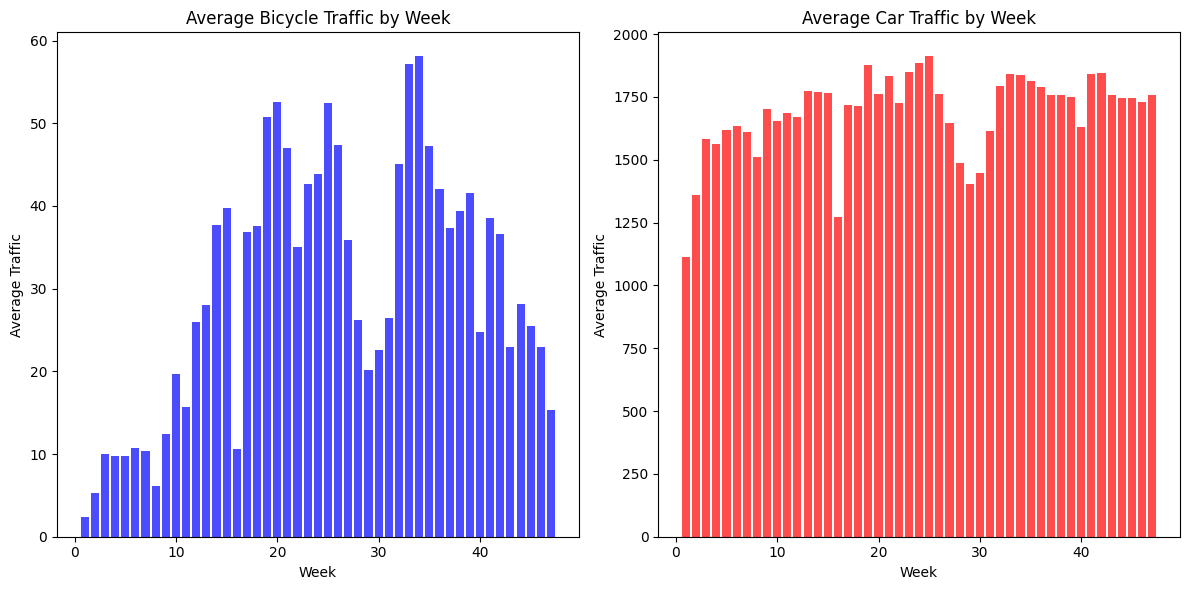

In [12]:
# Trafikkmønstre gjennom året, data

# Plot høyest biltraffik og sykkeltrafikk uke
plt.figure(figsize=(12, 6))

# Subplot for Bicycle Traffic
plt.subplot(1, 2, 1)
plt.bar(week_desc_s_traffic['uke'], week_desc_s_traffic['trafikk_mengde'], color='blue', alpha=0.7)
plt.title('Average Bicycle Traffic by Week')
plt.xlabel('Week')
plt.ylabel('Average Traffic')

# Subplot for Car Traffic
plt.subplot(1, 2, 2)
plt.bar(week_desc_c_traffic['uke'], week_desc_c_traffic['trafikk_mengde'], color='red', alpha=0.7)
plt.title('Average Car Traffic by Week')
plt.xlabel('Week')
plt.ylabel('Average Traffic')

# Display the plots
plt.tight_layout()
plt.show()

<!--2.b) Finn hvilke timer på døgnet som i gjennomsnitt har størst aktivitet for henholdsvis sykler og biler.-->
### 2.b)
> Bil: time 16,
> Sykkel: time 17

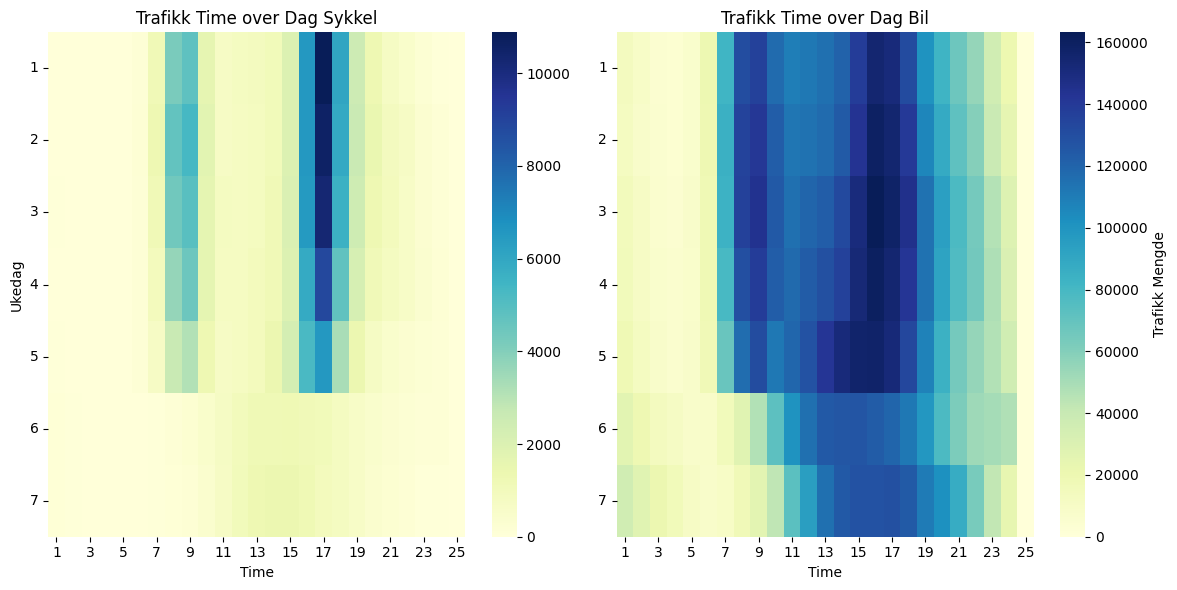

In [13]:
# Plot bil og sykkel trafikk pr time.

# Traffikmengde må være float for heatmap
time_desc_s_traffic['trafikk_mengde'] = time_desc_s_traffic['trafikk_mengde'].astype(float)
time_desc_c_traffic['trafikk_mengde'] = time_desc_c_traffic['trafikk_mengde'].astype(float)

pivot_table_s = time_desc_s_traffic.pivot_table(values='trafikk_mengde', index='dag', columns='time', aggfunc='sum', fill_value=0)
pivot_table_c = time_desc_c_traffic.pivot_table(values='trafikk_mengde', index='dag', columns='time', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12, 6))

# Subplot for Sykkel Trafikk
plt.subplot(1, 2, 1)
sns.heatmap(pivot_table_s, fmt='g', cmap='YlGnBu', cbar_kws={'label': ''})
plt.title('Trafikk Time over Dag Sykkel')
plt.xlabel('Time')
plt.ylabel('Ukedag')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# Subplot for Bil Trafikk
plt.subplot(1, 2, 2)
sns.heatmap(pivot_table_c, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Trafikk Mengde'})
plt.title('Trafikk Time over Dag Bil')
plt.xlabel('Time')
plt.ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<!--2.c) Undersøk om det finnes perioder (for eksempel ferier eller helligdager) hvor trafikken generelt er lav. Gi forslag til årsaker.-->
## 2.c)
    Figur under, viser fint hvor traffikken er generelt lav i forhold til ferier eller helligdager. Folk ferdes som regel vis dem ikke trenger.

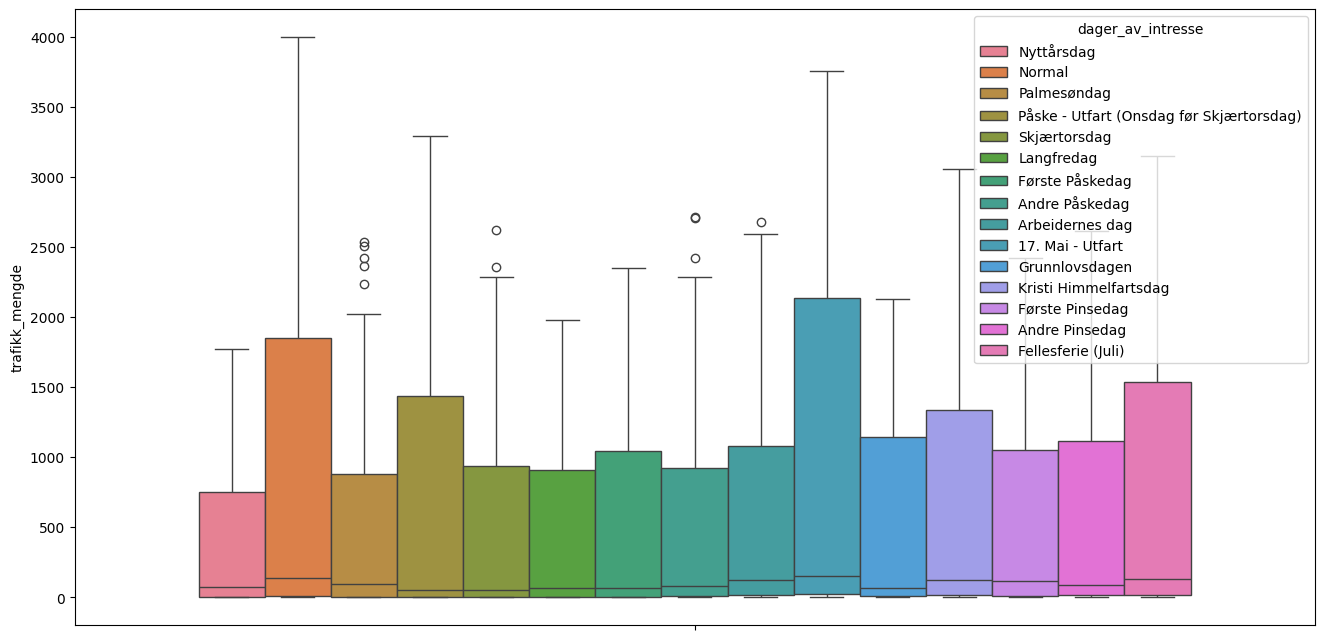

In [14]:
from datetime import date

def get_periodes_of_intrest(dato):
    if (dato.month == 12 and dato.day >= 20) or (dato.month == 1 and dato.day <= 1):
        return 'Jul/Nyttår'
    elif dato.month == 7:
        return 'Fellesferie'
    elif dato.month == 4 and dato.day >= 1 and dato.day <= 18:
        return 'Påskeferie' # Må justeres for riktig dato hvert år!
    else:
        return 'Normal'
def get_days_of_intrest_2025(dato):
    # 1. Definer offisielle helligdager (basert på din liste)
    helligdager = {
        date(2025, 1, 1): 'Nyttårsdag',
        
        # Påske 2025 (Varierer fra år til år)
        date(2025, 4, 13): 'Palmesøndag',
        date(2025, 4, 17): 'Skjærtorsdag',
        date(2025, 4, 18): 'Langfredag',
        date(2025, 4, 20): 'Første Påskedag',
        date(2025, 4, 21): 'Andre Påskedag',
        
        # Mai-dager
        date(2025, 5, 1): 'Arbeidernes dag',
        date(2025, 5, 17): 'Grunnlovsdagen',
        date(2025, 5, 29): 'Kristi Himmelfartsdag',
        
        # Pinse 2025 (Varierer fra år til år)
        date(2025, 6, 8): 'Første Pinsedag',
        date(2025, 6, 9): 'Andre Pinsedag',
        
        # Jul 2025
        date(2025, 12, 25): 'Første Juledag',
        date(2025, 12, 26): 'Andre Juledag',
        # Legg til 24. des. for å fange julaften
        date(2025, 12, 24): 'Julaften (Lille julaften/Utfart)',
    }
    
    # 2. Definer viktige utfartsdager (Dagen FØR en helligdag)
    # Dette er ofte dager med kaostrafikk
    utfartsdager = {
        date(2025, 4, 16): 'Påske - Utfart (Onsdag før Skjærtorsdag)',
        date(2025, 5, 16): '17. Mai - Utfart',
    }
    
    d = dato.date() # Sikre at vi bare jobber med dato-delen (uten tid)

    # Sjekk helligdager
    if d in helligdager:
        return helligdager[d]
    
    # Sjekk utfartsdager
    elif d in utfartsdager:
        return utfartsdager[d]
    
    # 3. Spesielle ferieperioder (for analyse, selv om de ikke er røde dager)
    # Dette fanger opp den vanlige 'Fellesferie'-trafikken i juli
    elif d.month == 7:
        return 'Fellesferie (Juli)'
        
    # 4. Returner 'Normal' for alle andre dager
    else:
        return 'Normal'

    
tdf_perioder = tdf.copy()
tdf_perioder['dager_av_intresse'] = tdf_perioder['dato'].apply(get_days_of_intrest_2025)

plt.figure(figsize=(16, 8)) 
sns.boxplot(data=tdf_perioder,y='trafikk_mengde', hue='dager_av_intresse')
plt.show()

In [15]:
# dato til datetime for lage år,uke,dag colonner med rader med det verdiene
vdf['dato'] = pd.to_datetime(vdf['dato'], format='%d.%m.%Y')
vdf['år'] = vdf['dato'].dt.isocalendar().year
vdf['uke'] = vdf['dato'].dt.isocalendar().week
vdf['dag'] = vdf['dato'].dt.isocalendar().day

# komma byttes til punktum for få enkel type konvertering til float i vær data
vdf['temperatur_dogn'] = vdf['temperatur_dogn'].astype(str).str.replace(',', '.').astype('float64')
vdf['nedbor_dogn'] = vdf['nedbor_dogn'].astype(str).str.replace(',', '.').astype('float64')

day_mean_traffic = tdf.copy().groupby(['trafikk_registreringspunkt','navn','år','måne','uke','dag']).agg({'trafikk_mengde':'mean'}).reset_index()

merged_df = pd.merge(
    vdf,
    day_mean_traffic,
    on=['år', 'uke', 'dag'],
    how='inner'
)

sykkel_df = merged_df[merged_df['trafikk_registreringspunkt'] == '55912B613537']
bil_df = merged_df[merged_df['trafikk_registreringspunkt'] == '79755V625294']

<!--3.a) Undersøk sammenhengen mellom sykkeltrafikk og temperatur. Gi en kort tolkning.-->
### 3.a)
    Ser ut folk ikke er så gla i å ferdes i kulla og potensiellt glatt føre, så d er veldig klar koralasjon mellom sykkel trafikk og tempratur.

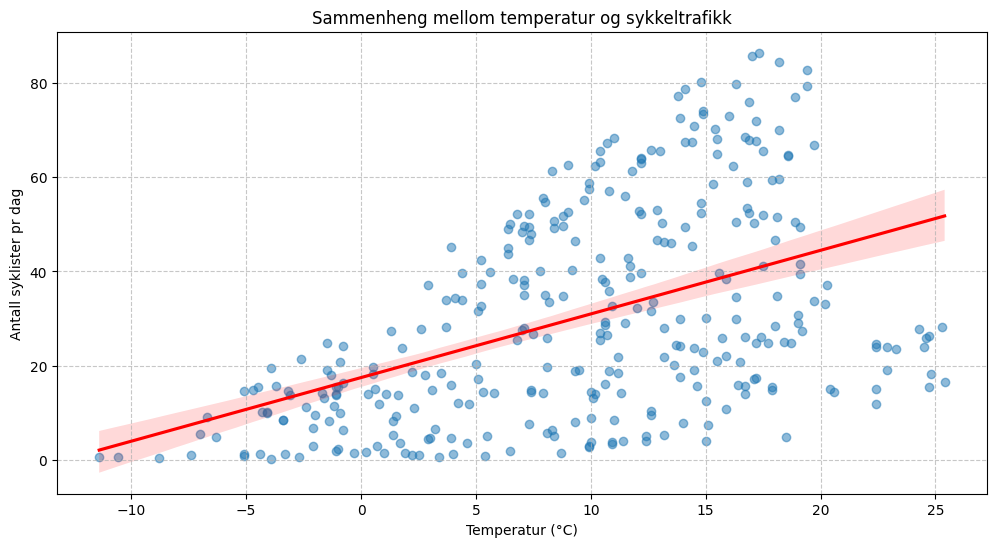

In [16]:
# tempratur vs sykkeltrafikk
plt.figure(figsize=(12, 6))

sns.regplot(data=sykkel_df, x='temperatur_dogn', y='trafikk_mengde', 
            scatter_kws={'alpha': 0.5}, order=1, line_kws={'color': 'red'})

plt.title('Sammenheng mellom temperatur og sykkeltrafikk')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Antall syklister pr dag')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<!--3.b) Undersøk sammenhengen mellom sykkeltrafikk og nedbør. Beskriv om nedbør har tydelig effekt.-->
### 3.b) 
    Intuisjonen sier at mest sansynlig er mindre sykkel trafikk ved nedbør, det samme sier dataene.

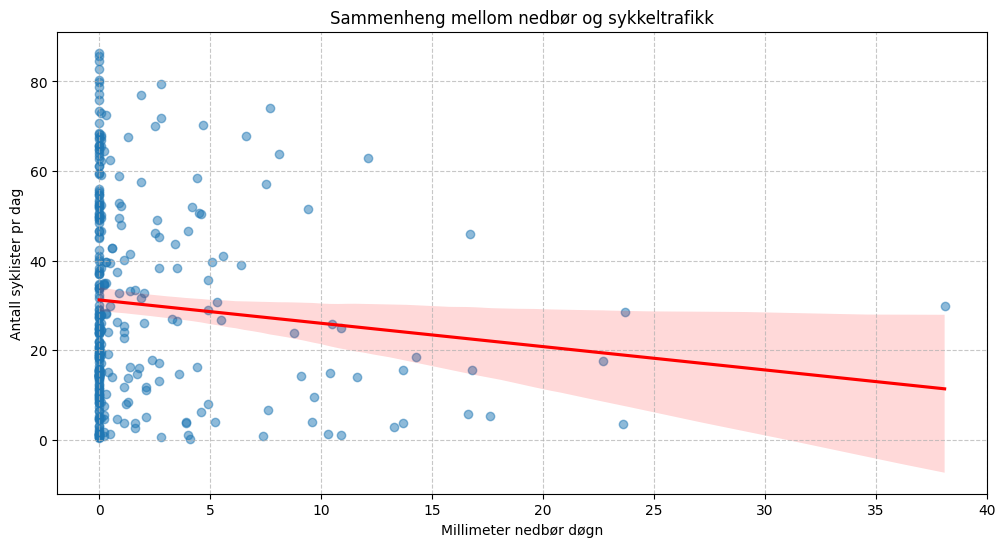

In [17]:
# Nedbør vs sykkeltrafikk
plt.figure(figsize=(12, 6))

sns.regplot(data=sykkel_df, x='nedbor_dogn', y='trafikk_mengde', 
            scatter_kws={'alpha': 0.5}, order=1, line_kws={'color': 'red'})

plt.title('Sammenheng mellom nedbør og sykkeltrafikk')
plt.xlabel('Millimeter nedbør døgn')
plt.ylabel('Antall syklister pr dag')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<!--3.c) Undersøk hvordan biltrafikken påvirkes av temperatur eller nedbør, og om mønsteret er annerledes enn for
sykkeltrafikk.-->
### 3.c)
    Bil ser ut til å ikke ha samme styrke i mønstret at folk liker varme dager. Posetiv korelasjon mellom trafikk og tempratur. Nedbør ser d og ut til at d er en negativ korelasjon mellom nedbør og trafikk, mer en man skulle tro.

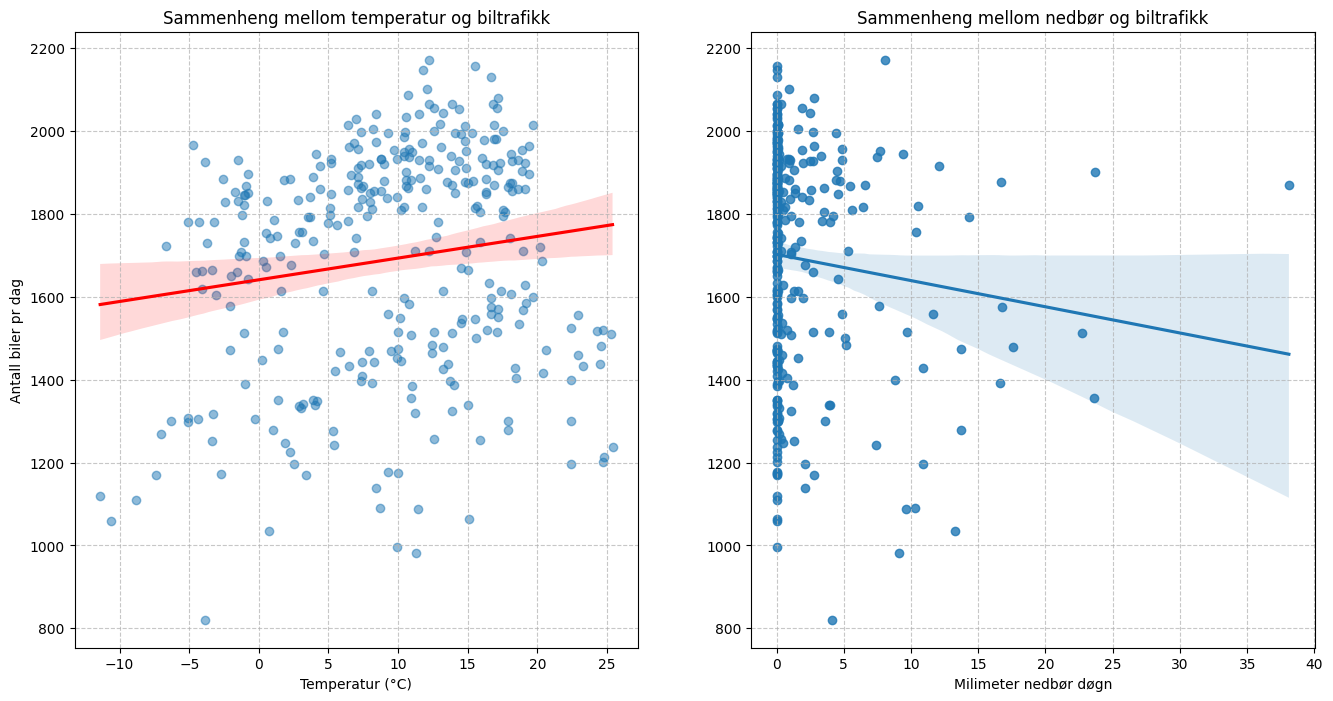

In [18]:
# Nedbør og tempratur vs biltrafikk
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.regplot(data=bil_df, x='temperatur_dogn', y='trafikk_mengde', 
            scatter_kws={'alpha': 0.5}, order=1, line_kws={'color': 'red'})
plt.title('Sammenheng mellom temperatur og biltrafikk')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Antall biler pr dag')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1,2,2)
sns.regplot(data=bil_df, x='nedbor_dogn', y='trafikk_mengde')
plt.title('Sammenheng mellom nedbør og biltrafikk')
plt.xlabel('Milimeter nedbør døgn')
plt.ylabel('')
plt.yticks()
plt.grid(True, linestyle='--', alpha=0.7)

<!--3.d) Undersøk om det finnes en sammenheng mellom biltrafikk og sykkeltrafikk. Diskuter om denne sammenhen-
gen virker sterk, svak eller utydelig.-->
### 3.d)
    Det er ganske sterk sammenheng, mellom sykkel og bil trafikk. I følge plot under.

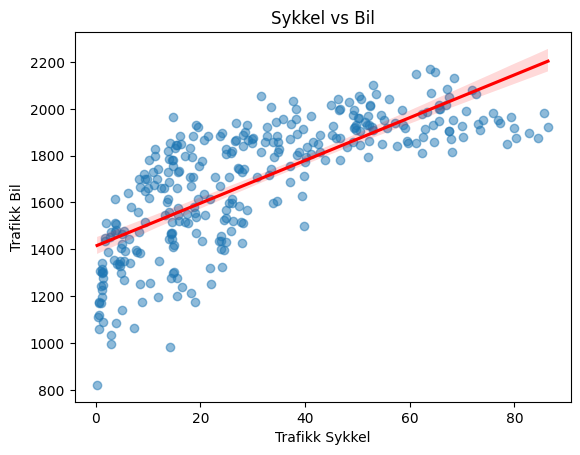

In [19]:
sns.regplot(y=bil_df['trafikk_mengde'], x=sykkel_df['trafikk_mengde'], 
            scatter_kws={'alpha': 0.5}, order=1, line_kws={'color': 'red'})
plt.title('Sykkel vs Bil')
plt.xlabel('Trafikk Sykkel')
plt.ylabel('Trafikk Bil')
plt.yticks()
plt.show()

<!--4.a) Utfør en klyngeanalyse for å gruppere timer etter aktivitetsnivå for syklister. Bruk relevante variabler som
tidspunkt, uke og måned.-->
### 4.a)

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kluster_analysis_utils import sesong_week_analysis, volum_analysis

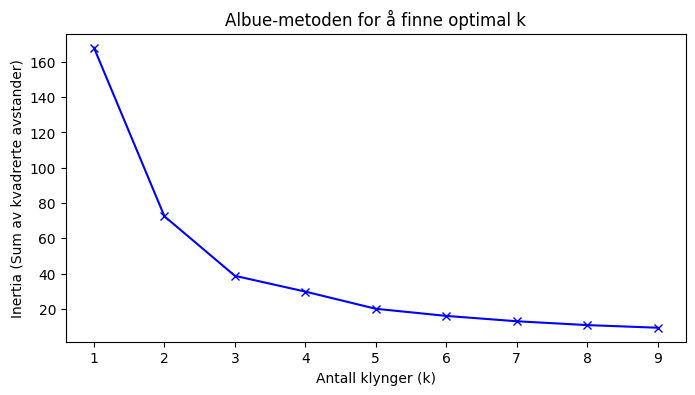


--- Gjennomsnittsverdier for de 5 klyngene ---


,måne,uke,trafikk_mengde,Volum,Sesong
Klynge,,,,,
0,4.9,20.4,47.3,Høy,Midt i året (Sommer)
1,8.9,37.6,43.5,Høy,Sent i året (Høst/Vinter)
2,2.1,7.6,11.8,Veldig Lav,Tidlig i året (Vår)
3,6.8,27.0,22.2,Middels-Høy,Midt i året (Sommer)
4,10.7,44.2,18.1,Middels-Lav,Sent i året (Høst/Vinter)


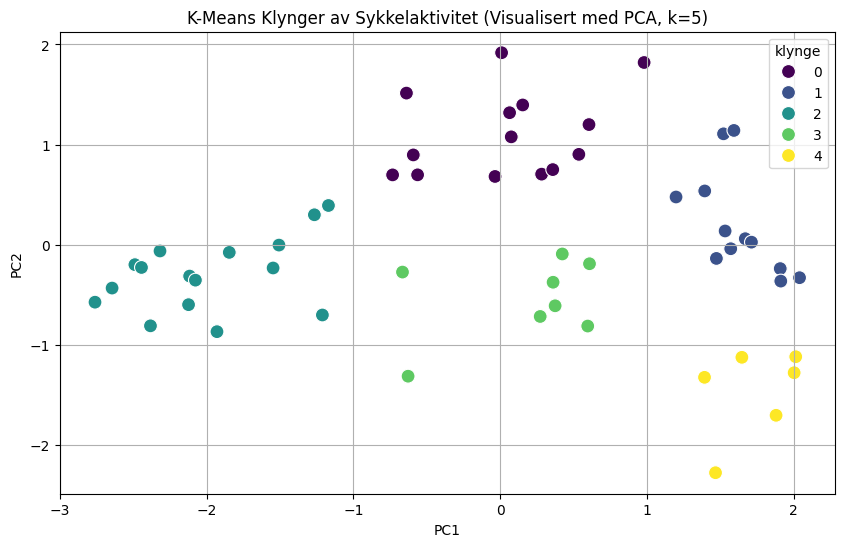

In [21]:
# klynge analyse for syklister

sykkel_df = tdf[tdf['trafikk_registreringspunkt'] == '55912B613537']

X = sykkel_df.copy().groupby(['måne','uke']).agg({'trafikk_mengde':'mean'}).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
range_values = range(1, 10)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, 'bx-')
plt.xlabel('Antall klynger (k)')
plt.ylabel('Inertia (Sum av kvadrerte avstander)')
plt.title('Albue-metoden for å finne optimal k')
plt.show()

optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['Klynge'] = kmeans.fit_predict(X_scaled)

print(f"\n--- Gjennomsnittsverdier for de {optimal_k} klyngene ---")
# Grupperer dataene og viser gjennomsnittet for de valgte variablene i hver klynge

cluster_summary = X.groupby('Klynge')[X.columns].mean().round(1)

# --- 1. Definer Terskelverdier for Tolkning (Som før) ---
max_traffic = cluster_summary['trafikk_mengde'].max()
min_traffic = cluster_summary['trafikk_mengde'].min()
median_traffic = cluster_summary['trafikk_mengde'].median()

# Trafikkterskler
PEAK_TRAFFIC = max_traffic * 0.85 # Høyere enn 85% av max
LOW_TRAFFIC = min_traffic * 1.5   # Lavere enn 150% av min (for å fange natt)


def tolkning(row):
    volum=volum_analysis(row['trafikk_mengde'],median_traffic,LOW_TRAFFIC,PEAK_TRAFFIC)
    sesong=sesong_week_analysis(row['uke'])
        
    # Returnerer en Pandas Series som automatisk blir til kolonner
    return pd.Series([volum,sesong], index=['Volum', 'Sesong'])
cluster_summery_view = cluster_summary.copy()
cluster_summery_view[['Volum','Sesong']] = cluster_summery_view.apply(tolkning, axis=1)
display(cluster_summery_view.drop(columns=['Klynge']))


max_traffic = cluster_summary['trafikk_mengde'].max()
min_traffic = cluster_summary['trafikk_mengde'].min()
median_traffic = cluster_summary['trafikk_mengde'].median()

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = principal_components, columns = ['PC1', 'PC2'])
pca_df['klynge'] = X['Klynge'].values # Legger til klyngenavn

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='klynge', palette='viridis', s=100)
plt.title(f'K-Means Klynger av Sykkelaktivitet (Visualisert med PCA, k={optimal_k})')
plt.grid(True)
plt.show()

<!--4.b) Gjenta klyngeanalysen for biltrafikk. Sammenlign resultatet med sykkelklyngene.-->
### 4.b)

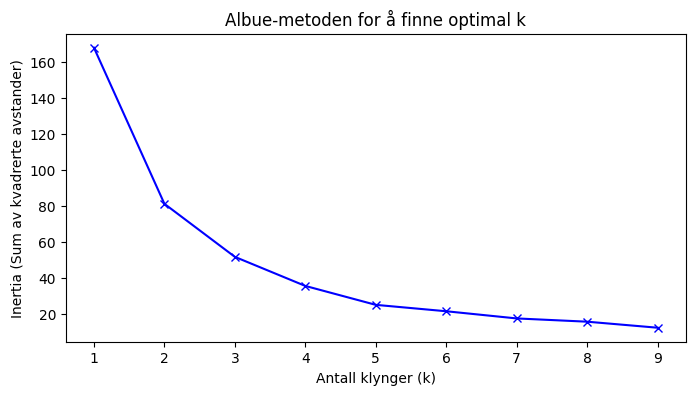


--- Gjennomsnittsverdier for de 5 klyngene ---


,måne,uke,trafikk_mengde,Volum,Sesong
Klynge,,,,,
0,4.9,20.4,1830.5,Høy,Midt i året (Sommer)
1,2.2,6.6,1296.5,Veldig Lav,Tidlig i året (Vår)
2,9.3,39.1,1773.5,Høy,Sent i året (Høst/Vinter)
3,7.2,28.6,1477.4,Veldig Lav,Midt i året (Sommer)
4,2.1,8.0,1657.5,Høy,Tidlig i året (Vår)


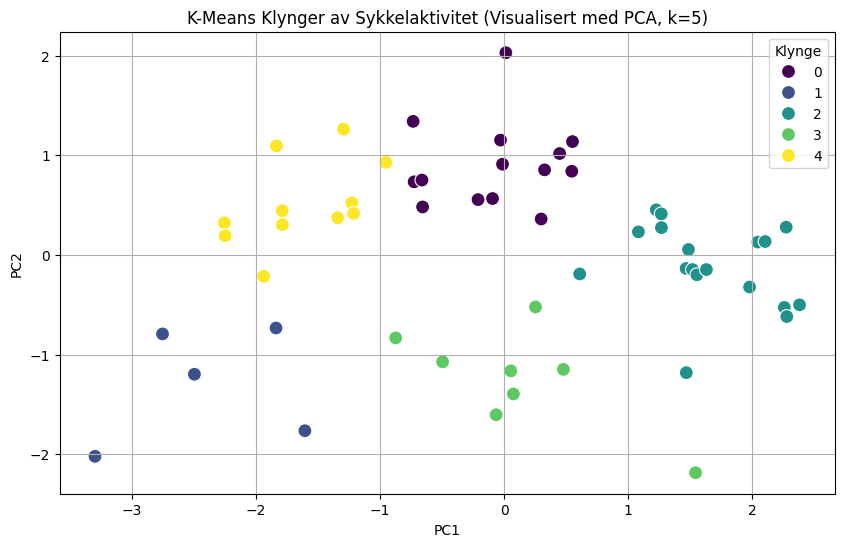

In [24]:
bil_df = tdf[tdf['trafikk_registreringspunkt'] == '79755V625294']
X = bil_df.copy().groupby(['måne','uke']).agg({'trafikk_mengde':'mean'}).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
range_values = range(1, 10)

for i in range_values:
    # n_init=10 unngår problemer med tilfeldig startpunkt
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, 'bx-')
plt.xlabel('Antall klynger (k)')
plt.ylabel('Inertia (Sum av kvadrerte avstander)')
plt.title('Albue-metoden for å finne optimal k')
plt.show()

optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X['Klynge'] = kmeans.fit_predict(X_scaled)

print(f"\n--- Gjennomsnittsverdier for de {optimal_k} klyngene ---")
# Grupperer dataene og viser gjennomsnittet for de valgte variablene i hver klynge
cluster_summary = X.groupby('Klynge')[X.columns].mean().round(1)

# --- 1. Definer Terskelverdier for Tolkning (Som før) ---
max_traffic = cluster_summary['trafikk_mengde'].max()
min_traffic = cluster_summary['trafikk_mengde'].min()
median_traffic = cluster_summary['trafikk_mengde'].median()

# Trafikkterskler
PEAK_TRAFFIC = max_traffic * 0.85 # Høyere enn 85% av max
LOW_TRAFFIC = min_traffic * 1.5   # Lavere enn 150% av min (for å fange natt)


def tolkning(row):
    volum=volum_analysis(row['trafikk_mengde'],median_traffic,LOW_TRAFFIC,PEAK_TRAFFIC)
    sesong=sesong_week_analysis(row['uke'])
        
    # Returnerer en Pandas Series som automatisk blir til kolonner
    return pd.Series([volum,sesong], index=['Volum', 'Sesong'])
cluster_summery_view = cluster_summary.copy()
cluster_summery_view[['Volum','Sesong']] = cluster_summery_view.apply(tolkning, axis=1)
display(cluster_summery_view.drop(columns=['Klynge']))

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = principal_components, columns = ['PC1', 'PC2'])
pca_df['Klynge'] = X['Klynge'].values # Legger til klyngenavn

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Klynge', palette='viridis', s=100)
plt.title(f'K-Means Klynger av Sykkelaktivitet (Visualisert med PCA, k={optimal_k})')
plt.grid(True)
plt.show()

<!-- 4.c) Beskriv hva som kjennetegner de ulike klyngene (for eksempel rush, helg, natt). -->
### 4.c)
    Klygene er litt forskjellige vis man tar med time sammen med uke, men d er mye likhetstrekk. Ikke uforventet i forhold til posetivtrend mellom di forskjellige. For gjøre d så simpelt som mulig så tok jeg måne og uke.

<!-- 4.d) Lag visualiseringer som viser utviklingen i antall syklister og bilister per time, per uke og per måned. Beskriv
kort hvordan mønstrene kan tolkes.-->
### 4.d)

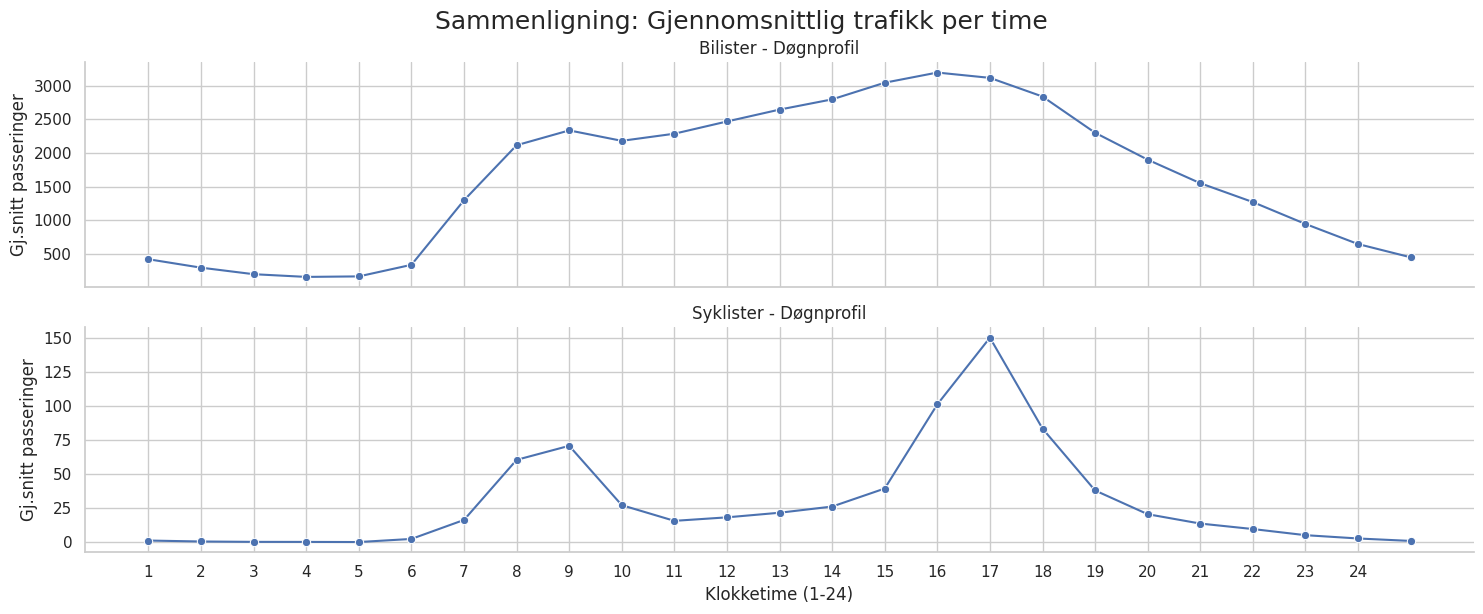

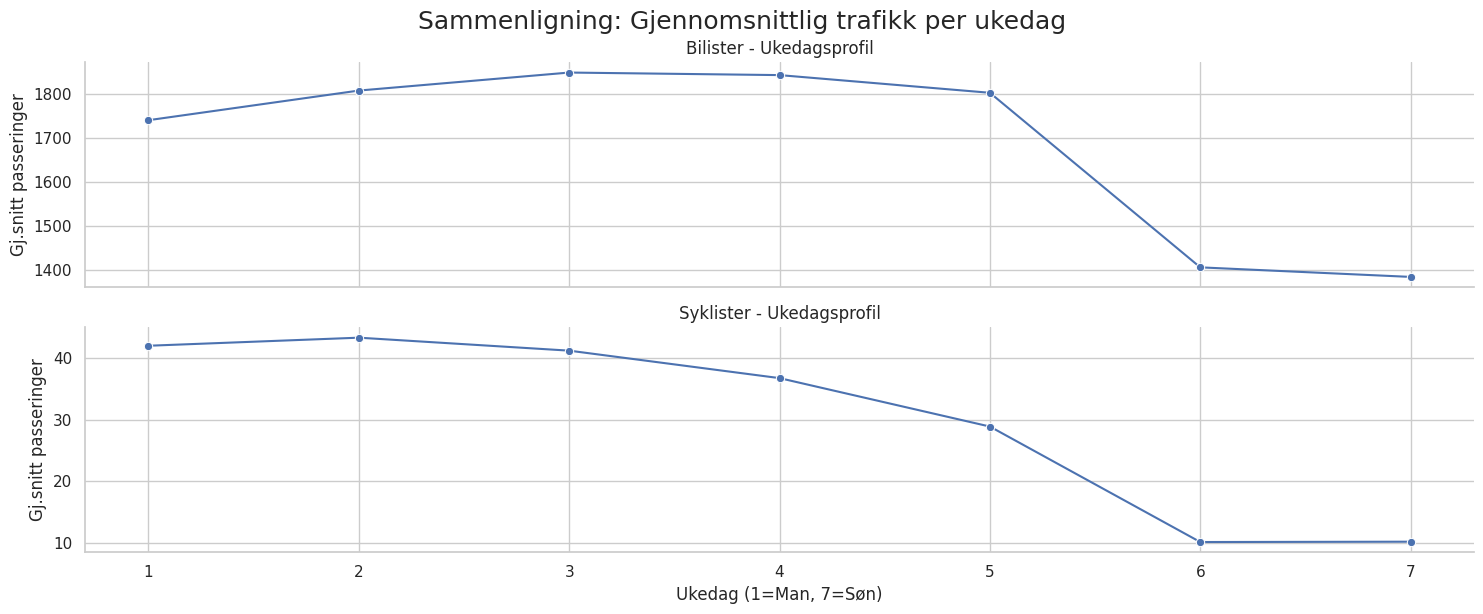

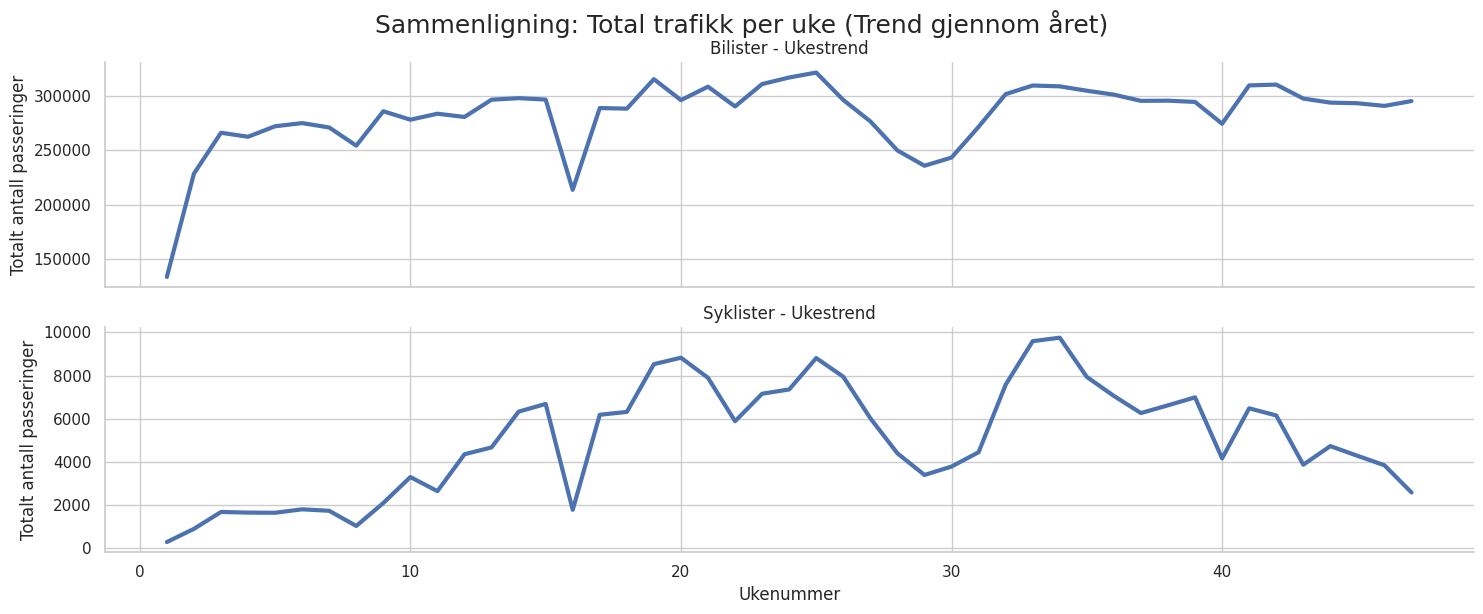

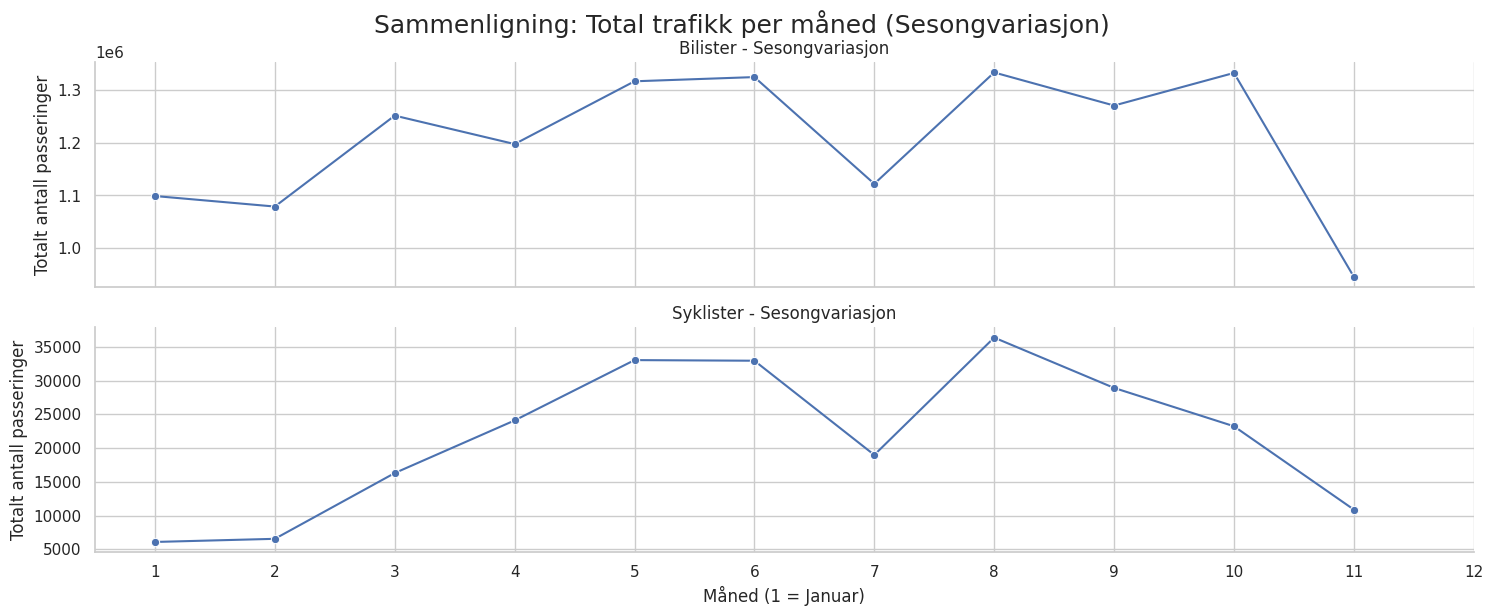

In [35]:
plot_1 = bil_df.copy()
plot_2 = sykkel_df.copy()
plot_2['Type'] = 'Sykelister'
plot_1['Type'] = 'Bilister'
df_combined = pd.concat([plot_1, plot_2])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)
fig, ax1 = plt.subplots()
plt.figure()
sns.lineplot(
    x='time',
    y='trafikk_mengde',
    hue='Type',
    estimator='mean',
    errorbar=None,
    marker="o",
    linewidth=2.5
)
plt.title("Sammenligning: Gjennomsnittlig trafikk per time", fontsize=16)
plt.xlabel("Klokketime (1-24)")
ax1.set_ylabel("Gjennomsnittlig antall passeringer")
plt.xticks(range(1, 25))
plt.legend(title='Trafikktype')
ax2 = ax1.twinx()
plt.show()

per_uke_combined = df_combined.groupby(['uke', 'Type'])['trafikk_mengde'].sum().reset_index()


sns.lineplot(
    data=per_uke_combined,
    x='uke',
    y='trafikk_mengde',
    hue='Type',
    linewidth=3
)
plt.title("Sammenligning: Total trafikk per uke (Trend gjennom året)", fontsize=16)
plt.xlabel("Ukenummer")
plt.ylabel("Totalt antall passeringer")
plt.legend(title='Trafikktype')
plt.show()


per_maned_combined = df_combined.groupby(['måne', 'Type'])['trafikk_mengde'].sum().reset_index()


# Stolpediagram for måned gir ofte best effekt for sesongvisning
sns.lineplot(
    data=per_maned_combined,
    x='måne',
    y='trafikk_mengde',
    shary
    hue='Type'
)import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plot_1 = bil_df.copy()
plot_2 = sykkel_df.copy()

plot_1['Type'] = 'Bilister'
plot_2['Type'] = 'Sykelister'

df_combined = pd.concat([plot_1, plot_2])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)

fig, ax1 = plt.subplots()

# Bilister (venstre y-akse)
sns.lineplot(
    data=df_combined[df_combined["Type"] == "Bilister"],
    x="time",
    y="trafikk_mengde",
    estimator="mean",
    errorbar=None,
    marker="o",
    linewidth=2.5,
    ax=ax1,
    label="Bilister"
)
ax1.set_ylabel("Gjennomsnittlig antall bilpasseringer")

# Sykelister (høyre y-akse)
ax2 = ax1.twinx()
sns.lineplot(
    data=df_combined[df_combined["Type"] == "Sykelister"],
    x="time",
    y="trafikk_mengde",
    estimator="mean",
    errorbar=None,
    marker="o",
    linewidth=2.5,
    ax=ax2,
    label="Sykelister"
)
ax2.set_ylabel("Gjennomsnittlig antall sykkelpasseringer")

ax1.set_title("Sammenligning: Gjennomsnittlig trafikk per time", fontsize=16)
ax1.set_xlabel("Klokketime (1–24)")
ax1.set_xticks(range(1, 25))

# Felles legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, title="Trafikktype")

plt.show()

plt.title("Sammenligning: Total trafikk per måned (Sesong)", fontsize=16)
plt.xlabel("Måned (1 = Januar)")
plt.ylabel("Totalt antall passeringer")
plt.legend(title='Trafikktype')
plt.show()


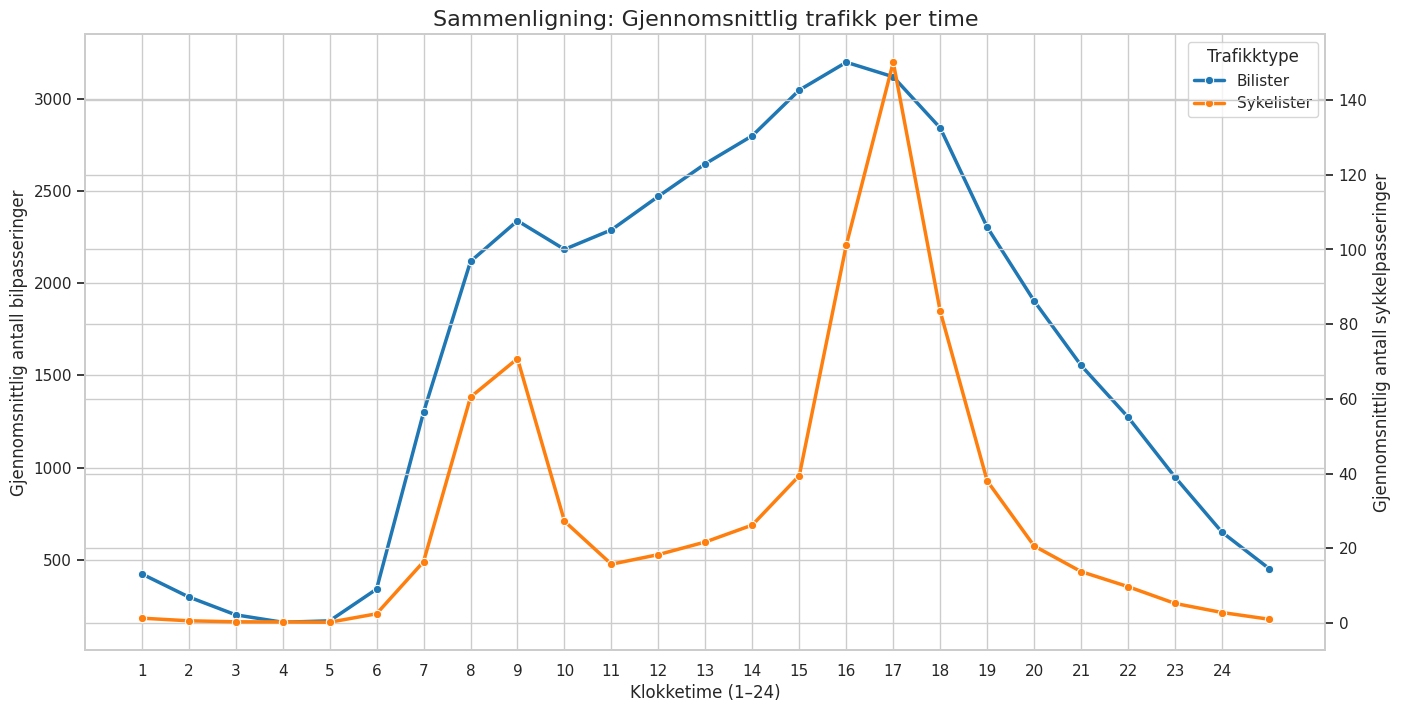

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plot_1 = bil_df.copy()
plot_2 = sykkel_df.copy()

plot_1['Type'] = 'Bilister'
plot_2['Type'] = 'Sykelister'

df_combined = pd.concat([plot_1, plot_2])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)

fig, ax1 = plt.subplots()

# Bilister (venstre y-akse)
sns.lineplot(
    data=df_combined[df_combined["Type"] == "Bilister"],
    x="time",
    y="trafikk_mengde",
    estimator="mean",
    errorbar=None,
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    ax=ax1,
    label="Bilister",
    legend=False
)
ax1.set_ylabel("Gjennomsnittlig antall bilpasseringer")

# Sykelister (høyre y-akse)
ax2 = ax1.twinx()
sns.lineplot(
    data=df_combined[df_combined["Type"] == "Sykelister"],
    x="time",
    y="trafikk_mengde",
    estimator="mean",
    errorbar=None,
    marker="o",
    linewidth=2.5,
    color="tab:orange",
    ax=ax2,
    label="Sykelister",
    legend=False
)
ax2.set_ylabel("Gjennomsnittlig antall sykkelpasseringer")

ax1.set_title("Sammenligning: Gjennomsnittlig trafikk per time", fontsize=16)
ax1.set_xlabel("Klokketime (1–24)")
ax1.set_xticks(range(1, 25))

# Felles legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, title="Trafikktype")

plt.show()


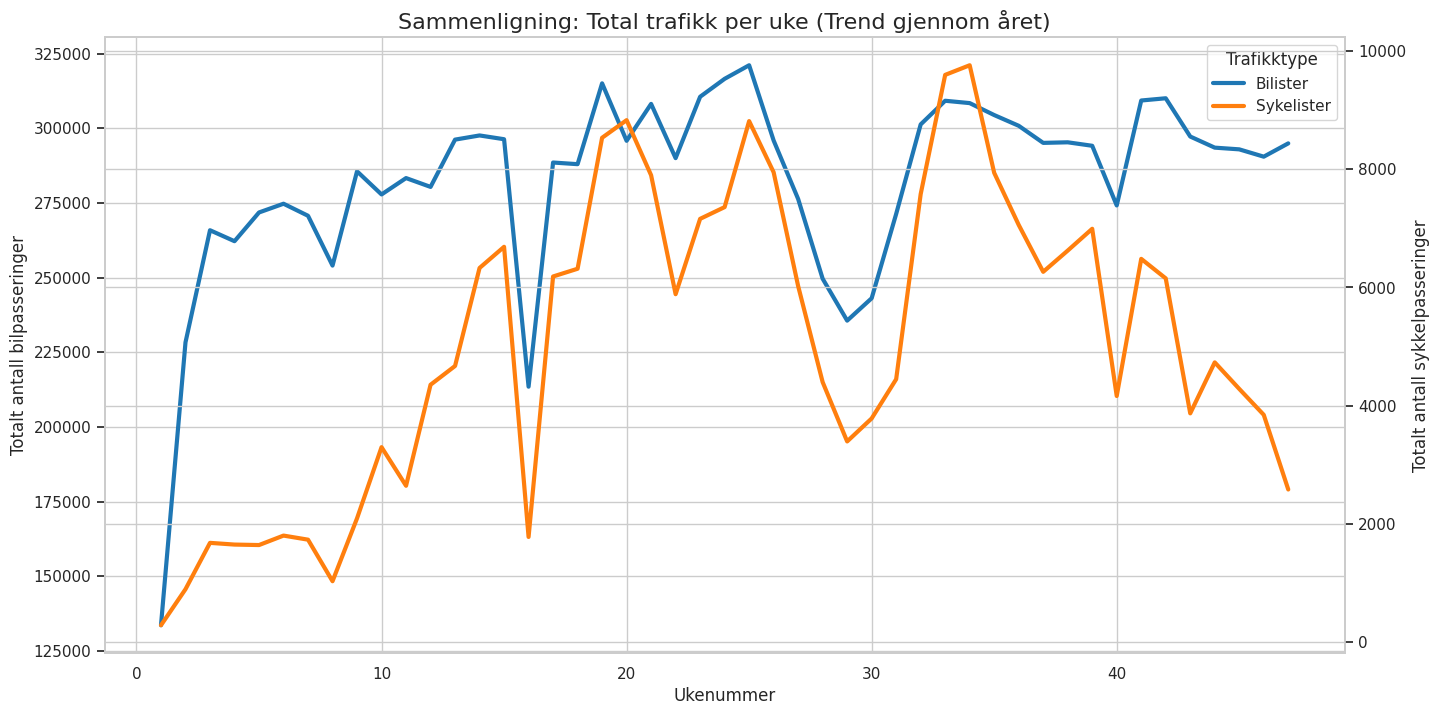

In [48]:
per_uke_combined = (
    df_combined
    .groupby(['uke', 'Type'])['trafikk_mengde']
    .sum()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Bilister
sns.lineplot(
    data=per_uke_combined[per_uke_combined["Type"] == "Bilister"],
    x="uke",
    y="trafikk_mengde",
    linewidth=3,
    color="tab:blue",
    ax=ax1,
    label="Bilister",
    legend=False
)
ax1.set_ylabel("Totalt antall bilpasseringer")

# Sykelister
ax2 = ax1.twinx()
sns.lineplot(
    data=per_uke_combined[per_uke_combined["Type"] == "Sykelister"],
    x="uke",
    y="trafikk_mengde",
    linewidth=3,
    color="tab:orange",
    ax=ax2,
    label="Sykelister",
    legend=False
)
ax2.set_ylabel("Totalt antall sykkelpasseringer")

ax1.set_title("Sammenligning: Total trafikk per uke (Trend gjennom året)", fontsize=16)
ax1.set_xlabel("Ukenummer")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, title="Trafikktype")

plt.show()


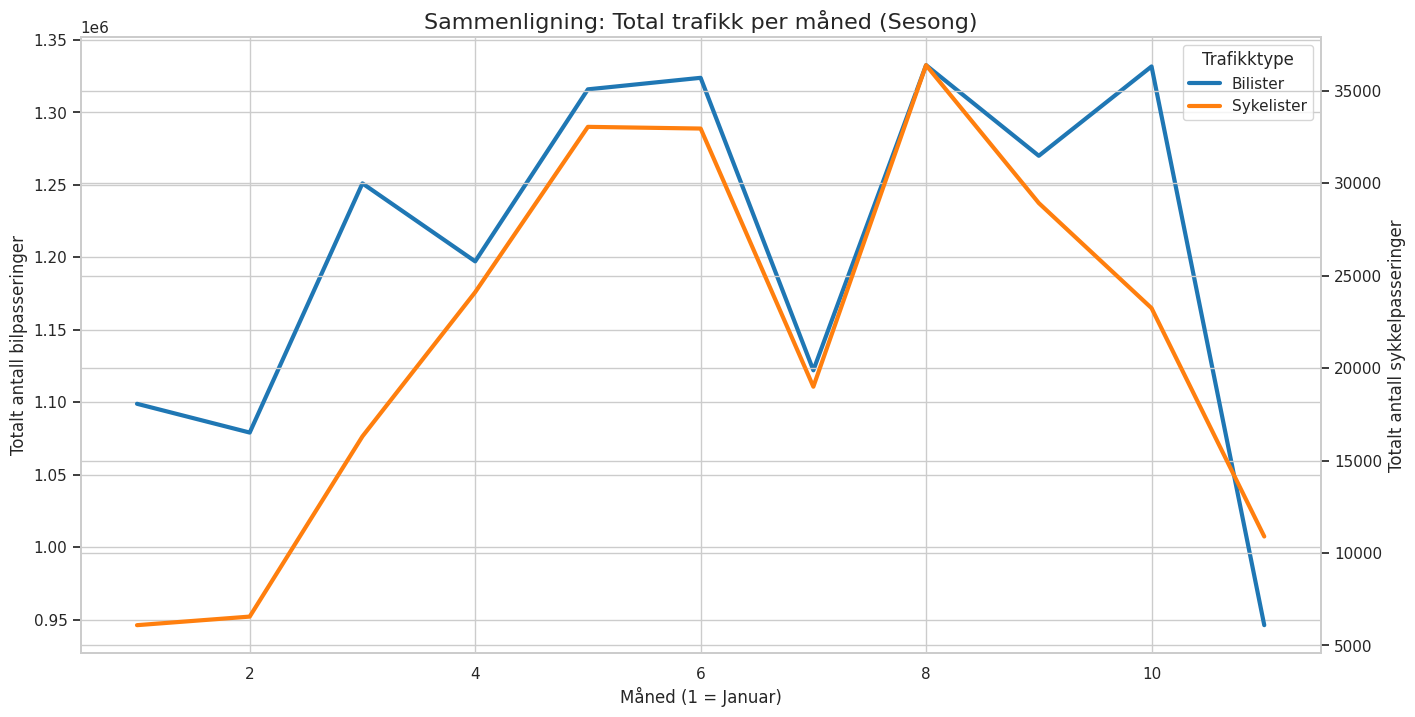

In [49]:
per_maned_combined = (
    df_combined
    .groupby(['måne', 'Type'])['trafikk_mengde']
    .sum()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Bilister
sns.lineplot(
    data=per_maned_combined[per_maned_combined["Type"] == "Bilister"],
    x="måne",
    y="trafikk_mengde",
    linewidth=3,
    color="tab:blue",
    ax=ax1,
    label="Bilister",
    legend=False
)
ax1.set_ylabel("Totalt antall bilpasseringer")

# Sykelister
ax2 = ax1.twinx()
sns.lineplot(
    data=per_maned_combined[per_maned_combined["Type"] == "Sykelister"],
    x="måne",
    y="trafikk_mengde",
    color="tab:orange",
    linewidth=3,
    ax=ax2,
    label="Sykelister",
    legend=False
)
ax2.set_ylabel("Totalt antall sykkelpasseringer")

ax1.set_title("Sammenligning: Total trafikk per måned (Sesong)", fontsize=16)
ax1.set_xlabel("Måned (1 = Januar)")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, title="Trafikktype")

plt.show()
